<p style="padding: 20px; background-color: #2ecc71; color: white; border-radius: 10px; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 22px; font-weight: bold;">
Human Capital Insights: Segmentación Sociodemográfica y Estrategias de Fidelización del Talento
<br>
<span style="font-size: 16px; font-weight: normal;">
Equipo de Análisis de Perfil y Desempeño
</span>
</p>

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from kmodes.kprototypes import KPrototypes
RRHH_full = pd.read_csv('full_RRHH.csv')


## <p style="padding: 15px; background-color: #2c3e50; color: white; border-radius: 8px; font-family: sans-serif; text-align: center;"> Segmentación Inteligente mediante Machine Learning (Clustering K-Means)</p>


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Agrupamos por ID para tener perfiles únicos
df_id = RRHH_full.groupby('ID').agg({
    'Age': 'mean',
    'Body_mass_index': 'mean',
    'Son': 'mean',
    'Education': 'first',
    'Social_drinker': 'max',
    'Social_smoker': 'max'
}).reset_index()

# 2. Transformamos variables categóricas a números (One-Hot Encoding)
# Esto convierte 'Education' en columnas como 'Education_High School', etc.
df_numeric = pd.get_dummies(df_id, columns=['Education', 'Social_drinker', 'Social_smoker'])

# 3. Seleccionamos las columnas para la IA (excluimos el ID)
X = df_numeric.drop(columns=['ID'])

# 4. Escalado: Fundamental para que la Edad no domine sobre los 0/1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

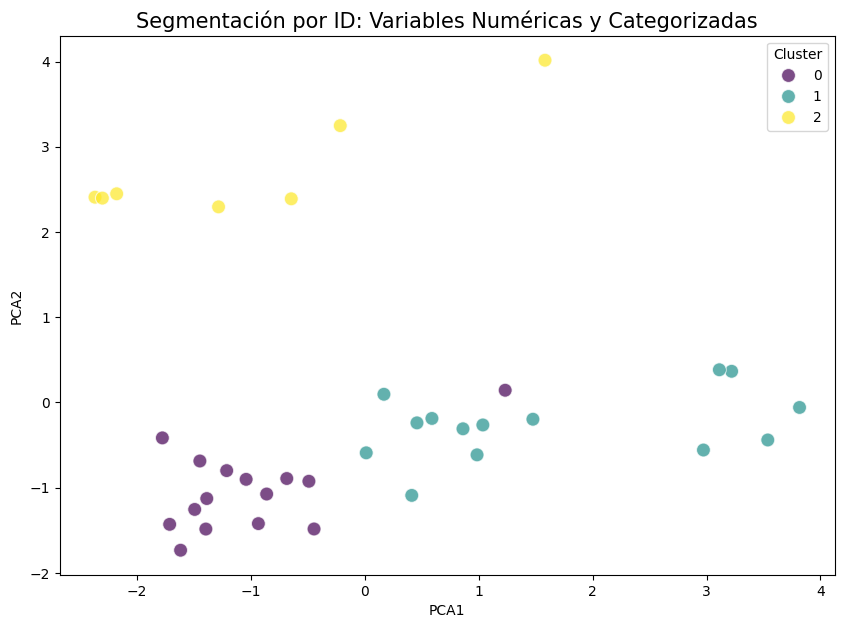

In [7]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Aplicamos K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_id['Cluster'] = kmeans.fit_predict(X_scaled)

# Reducimos a 2D para la foto
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_id['PCA1'] = pca_data[:, 0]
df_id['PCA2'] = pca_data[:, 1]

# Gráfico estético
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_id, x='PCA1', y='PCA2', 
    hue='Cluster', palette='viridis', 
    s=100, alpha=0.7, edgecolor='w'
)


plt.title('Segmentación por ID: Variables Numéricas y Categorizadas', fontsize=15)
plt.show()

In [8]:
import plotly.express as px

# Creamos el gráfico interactivo
fig = px.scatter(
    df_id, 
    x='PCA1', 
    y='PCA2', 
    color='Cluster',               # El equivalente a 'hue'
    color_continuous_scale='Viridis', # Mantenemos tu paleta original
    title='Segmentación por ID: Variables Numéricas y Categorizadas',
    labels={'PCA1': 'Componente Principal 1', 'PCA2': 'Componente Principal 2'},
    hover_data=['Cluster'],       # Puedes añadir aquí más columnas, ej: ['ID', 'Edad']
    opacity=0.7
)

# Ajustes estéticos adicionales
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='White')))
fig.update_layout(
    legend_title_text='Cluster',
    template='plotly_white', # Fondo limpio
    title_font_size=20
)

fig.show()

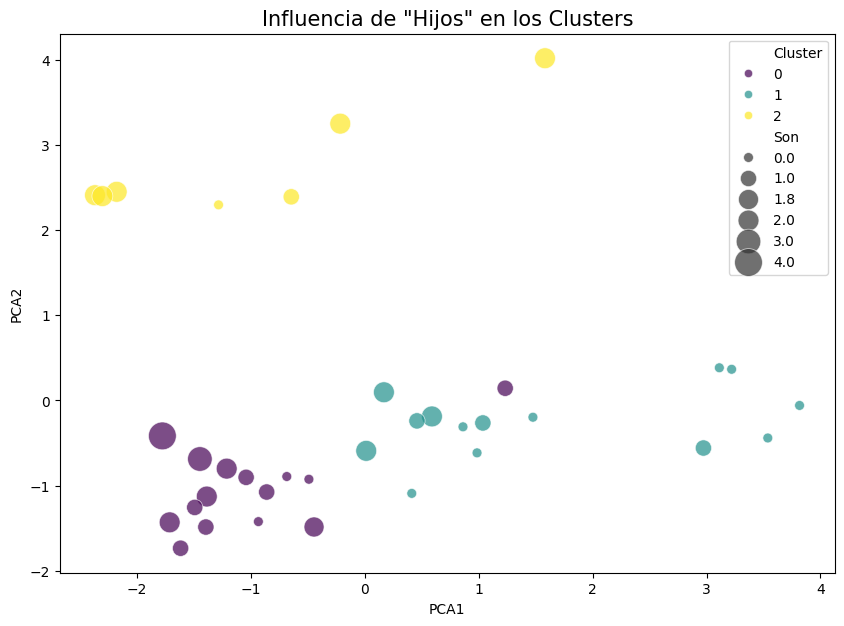

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_id, 
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    size='Son',       # <--- AQUÍ ESTÁ: El tamaño del punto ahora representa los hijos
    sizes=(50, 400),  # Rango de tamaño de los puntos
    palette='viridis', 
    alpha=0.7, 
    edgecolor='w'
)
plt.title('Influencia de "Hijos" en los Clusters', fontsize=15)
plt.show()

In [17]:
import plotly.express as px

# Aseguramos que Cluster sea un string para colores discretos
df_id['Cluster'] = df_id['Cluster'].astype(str)

fig = px.scatter(
    df_id, 
    x='PCA1', 
    y='PCA2', 
    color='Cluster',
    size='Son',
    size_max=25,
    # --- CAMBIOS AQUÍ ---
    hover_name=df_id.index,    # Si el ID es el índice del DataFrame
    # hover_name='ID_Column',  # Descomenta esta si tu ID es una columna llamada 'ID_Column'
    hover_data={
        'PCA1': False,         # Ocultamos coordenadas si no son útiles para el usuario
        'PCA2': False, 
        'Cluster': True, 
        'Son': True
    },
    # ---------------------
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Segmentación Interactiva: Análisis de Clusters e Hijos por ID',
    template='plotly_white'
)

fig.update_traces(marker=dict(line=dict(width=1, color='White')))
fig.update_layout(
    legend_title_text='Cluster',
    hoverlabel=dict(bgcolor="white", font_size=14) # Mejora la legibilidad del ID
)

fig.show()

In [10]:

counts = df_id['Cluster'].value_counts().rename('Num_Empleados')

pcts = (df_id['Cluster'].value_counts(normalize=True) * 100).rename('%_Plantilla')

means = df_id.groupby('Cluster')[['Age', 'Body_mass_index', 'Son']].mean()


habits = df_id.groupby('Cluster')[['Social_drinker', 'Social_smoker']].mean() * 100

# 5. Unimos todo en un único DataFrame "bonitinho"
df_resumen = pd.concat([counts, pcts, means, habits], axis=1).round(2)

# Ordenamos por Cluster para que sea legible
df_resumen = df_resumen.sort_index()

# Mostramos el resultado
print("📊 Resumen Ejecutivo de Clusters por ID:")
display(df_resumen)

📊 Resumen Ejecutivo de Clusters por ID:


,Num_Empleados,%_Plantilla,Age,Body_mass_index,Son,Social_drinker,Social_smoker
Cluster,,,,,,,
0,15,41.67,36.96,27.88,1.39,100.00,0.0
1,14,38.89,38.71,25.71,0.64,0.00,0.0
2,7,19.44,40.14,24.57,1.57,57.14,100.0


In [13]:
import plotly.express as px

# Creamos el gráfico interactivo
fig = px.scatter(
    df_id, 
    x='PCA1', 
    y='PCA2', 
    color='Cluster',               # El equivalente a 'hue'
    color_continuous_scale='Viridis', # Mantenemos tu paleta original
    title='Segmentación por ID: Variables Numéricas y Categorizadas',
    labels={'PCA1': 'Componente Principal 1', 'PCA2': 'Componente Principal 2'},
    hover_data=['Cluster'],       # Puedes añadir aquí más columnas, ej: ['ID', 'Edad']
    opacity=0.7
)

# Ajustes estéticos adicionales
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='White')))
fig.update_layout(
    legend_title_text='Cluster',
    template='plotly_white', # Fondo limpio
    title_font_size=20
)

fig.show()

<p style="padding: 20px; background-color: #2ecc71; color: white; border-radius: 10px; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 22px; font-weight: bold;">
KPIs<br>
<span style="font-size: 16px; font-weight: normal;">

</span>
</p>

In [19]:

total_empleados = RRHH_full['ID'].nunique()
ausentes = RRHH_full[RRHH_full['Absenteeism_hours'] > 0]['ID'].nunique()
pct_ausentes = (ausentes / total_empleados) * 100


mes_pico_num = RRHH_full.groupby('Month_absence')['Absenteeism_hours'].sum().idxmax()


motivo_modal_id = RRHH_full['Reason_Description'].mode()[0]


eficiencia_relativa = RRHH_full['Hit_target'].mean() / RRHH_full['Work_load_Average_day'].mean()

print(f"KPI 1: Porcentaje de Ausentes: {pct_ausentes:.2f}%")
print(f"KPI 2: Mes con mayor impacto: Mes {mes_pico_num}")
print(f"KPI 3: Motivo más frecuente (ID): {motivo_modal_id}")
print(f"KPI 4: Índice de Eficiencia: {eficiencia_relativa:.4f}")

KPI 1: Porcentaje de Ausentes: 91.67%
KPI 2: Mes con mayor impacto: Mes 3
KPI 3: Motivo más frecuente (ID): Medical consultation
KPI 4: Índice de Eficiencia: 0.3475


**KPI 1:** Porcentaje de Empleados Ausentes (91.7%): Representa la incidencia global. Se calcula dividiendo el número de empleados con al menos una ausencia por el total de empleados. Un valor del 91.7% indica que el absentismo es un comportamiento generalizado en la plantilla.<br>

**KPI 2:** Mes Pico de Carga (Mes 3): Identifica el momento del año con mayor acumulación de horas de ausencia mediante la función matemática $\arg \max$. El Mes 3 (marzo) es el punto crítico que requiere mayor planificación de recursos.KPI 3: Motivo Modal (Medical Consultation): Determina la causa raíz más frecuente de las ausencias. Las consultas médicas son la razón predominante, lo que sugiere una oportunidad para implementar políticas de salud preventiva.<br>

**KPI 3:** KPI 3: Motivo más frecuente (ID): Medical consultation


**KPI 4:** Índice de Eficiencia Relativa (0.35): Mide la productividad real comparando los objetivos cumplidos (Hit target) frente a la carga de trabajo diaria. Un índice de 0.35 es bajo, señalando que el absentismo afecta significativamente la capacidad operativa.